# Archival Bias Detection via PD Coverage Ratios

This notebook calculates and compares phylogenetic diversity coverage ratios across Dutch National Archives subcollections to quantify institutional bias patterns.

**Methodology**: Based on Faith's Phylogenetic Diversity and Chao1 unseen diversity estimation.

**Key Ratios**:
- **Coverage Ratio**: `collection_pd / gtaa_total_pd` - What fraction of total possible conceptual space does this collection cover?
- **Completeness Ratio**: `collection_pd / (collection_pd + unseen_pd)` - Within the conceptual territory this collection does cover, how thoroughly is it documented? High completeness = only few missing subjects that _should_ be there based on what we observe. Low completeness = Lots or related concepts are missing -> incomplete preservation. 
- **Efficiency Ratio**: `coverage_ratio / log(collection_size)` - How efficient is the collection at covering conceptual space? High efficiency = small specialized collections that cover conceptual breadt, low efficiency = massive collections with repetitive content 

**Interpretation Guidelines**:
1. Lower-Right (in scatter) High Coverage + Low Completeness. Collection touches many domains but is under-sampled in each. Good candidate for targeted expansion.
2. Lower-Left Low Coverage - Low Completeness = This collection has both institutional blind spots AND incomplete sampling within its domain.
3. Low Coverage + High Completeness = This collection thoroughly documents its narrow domain. The low coverage reflects institutional focus, not sampling bias.
4. High Coverage + High completeness = WOW! 

## 1. Setup and Imports

In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import os
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
import sys
warnings.filterwarnings('ignore')

# Add src directory to Python path
sys.path.append('src')

# Import local modules from src directory
from src.graph_builder import GTAAGraphBuilder
from src.faith_pd import FaithPDCalculator
from src.unseen_pd import UnseenPDEstimator
from src.archival_bias_detection import ArchivalBiasDetector

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10


## 2. Archival Bias Detector (Imported from archival_bias_detection.py)

The `ArchivalBiasDetector` class is imported from `archival_bias_detection.py` to avoid code duplication. This class provides all the functionality needed for analyzing archival bias patterns using phylogenetic diversity coverage ratios.

In [2]:
# Configuration
gtaa_csv_path = Path("data/external/gtaa_melvin.csv")
parquet_path = Path("data/processed/photos_archive.parquet")

In [ ]:

# Check if files exist
if not parquet_path.exists():
    print(f"Error: Processed data file not found at {parquet_path}")
elif not gtaa_csv_path.exists():
    print(f"Error: GTAA vocabulary file not found at {gtaa_csv_path}")
else:
    print("All required files found")



print("Initializing ArchivalBiasDetector...")
detector = ArchivalBiasDetector(gtaa_csv_path, min_collection_size=1000)

# Build graph with automatic deduplication check
print("Building graph with integrated deduplication checking...")
detector.build_graph(apply_deduplication=False)
print("Multi-parent nodes will be fixed using maxfreq strategy during analysis")

print("Loading and filtering data...")
df = detector.load_and_filter_data(parquet_path)

# Calculate global PD
global_pd = detector.calculate_global_gtaa_pd()

# This method will automatically apply data-informed deduplication and run the full analysis
results = detector.analyze_archival_bias(df, 'fotocollectie')

print("RESULTS:")
print("=" * 60)

# Display key metrics
print(f"Global GTAA PD: {results['global_pd']:.2f}")
print(f"Collections analyzed: {len(results['collection_results'])}")

# Show summary statistics
coverage_ratios = [r['coverage_ratio'] for r in results['collection_results']]
completeness_ratios = [r['completeness_ratio'] for r in results['collection_results']]
efficiency_ratios = [r['efficiency_ratio'] for r in results['collection_results']]

print(f"\nCoverage Ratios (breadth):")
print(f"  Mean: {np.mean(coverage_ratios):.3f}")
print(f"  Median: {np.median(coverage_ratios):.3f}")
print(f"  Range: {min(coverage_ratios):.3f} - {max(coverage_ratios):.3f}")

print(f"\nCompleteness Ratios (depth):")
print(f"  Mean: {np.mean(completeness_ratios):.3f}")
print(f"  Median: {np.median(completeness_ratios):.3f}")
print(f"  Range: {min(completeness_ratios):.3f} - {max(completeness_ratios):.3f}")

print(f"\n Efficiency Ratios:")
print(f"  Mean: {np.mean(efficiency_ratios):.3f}")
print(f"  Median: {np.median(efficiency_ratios):.3f}")
print(f"  Range: {min(efficiency_ratios):.3f} - {max(efficiency_ratios):.3f}")

# Show most biased collections
sorted_results = sorted(results['collection_results'], 
                        key=lambda x: x['coverage_ratio'])

print(f"\n Collections with Lowest Coverage (highest bias):")
for result in sorted_results[:5]:
    print(f"  {result['fotocollectie']}: {result['coverage_ratio']:.3f} "
            f"({result['collection_pd']:.1f}/{results['global_pd']:.1f})")

print(f"\nCollections with Highest Coverage:")
for result in sorted_results[-5:]:
    print(f"  {result['fotocollectie']}: {result['coverage_ratio']:.3f} "
            f"({result['collection_pd']:.1f}/{results['global_pd']:.1f})")

# Create results DataFrame for visualizations
results_df = pd.DataFrame(results['collection_results'])
results_df = results_df.sort_values('coverage_ratio', ascending=False).reset_index(drop=True)
results_df.rename(columns={'fotocollectie': 'subcollection'}, inplace=True)

# Verify final graph status
final_is_tree = nx.is_tree(detector.graph)
final_multi_parent = [
    node for node in detector.graph.nodes() 
    if node != "_DUMMY_ROOT_" and len(list(detector.graph.predecessors(node))) > 1
]

print(f"\nFINAL VERIFICATION:")
print(f"  Graph is tree: {final_is_tree}")
print(f"  Multi-parent nodes remaining: {len(final_multi_parent)}")
print("Results stored in 'results', 'results_df' variables")


        



All required files found
Initializing ArchivalBiasDetector...
Building graph with integrated deduplication checking...
Building GTAA vocabulary graph...
Building GTAA vocabulary graph...
  Adding edges to graph...


Processing edges: 100%|██████████| 3442/3442 [00:00<00:00, 19063.36it/s]


  Adding 3498 unique nodes...


Adding nodes: 100%|██████████| 3498/3498 [00:00<00:00, 2030119.74it/s]


  Connecting 251 root nodes to dummy root...
Graph built: 3499 nodes, 3693 edges
Multi-parent nodes will be fixed using maxfreq strategy during analysis
Loading and filtering data...
Loading data from data/processed/photos_archive.parquet...
Loaded 991,372 records
Deserializing subjects_list from JSON strings...
Deserializing persons from JSON strings...
Deserializing locations_standardized from JSON strings...
991,372 records have subjects
Calculating global GTAA PD...
Global GTAA PD: 3498.00
Starting archival bias analysis...
Applying deduplication...
  Calculating subject frequencies from dataset for informed deduplication...
Found 18936 unique subjects in dataset
 Total subject occurrences: 3,048,340
Deduplicating 186 nodes with multiple parents (strategy: maxfreq)...


Deduplicating nodes: 100%|██████████| 186/186 [00:00<00:00, 41970.12it/s]

Deduplication complete: processed 186 nodes, removed 195 edges
Data-driven deduplication complete:
Multi-parent nodes remaining: 0
Calculating global GTAA PD...


Global GTAA PD: 3498.00
Analyzing all collections...
Found 26 collections
17 collections meet minimum size requirement (1000 images)
Processing: Fotocollectie Spaarnestad Onderwerpen (397084 images)
Processing: Fotocollectie Anefo (376056 images)
Processing: Fotocollectie Elsevier (42415 images)
Processing: Fotocollectie Dienst voor Legercontacten Indonesië (38559 images)
Processing: Fotocollectie Rijksvoorlichtingsdienst Eigen (33085 images)
Processing: Fotocollectie Van de Poll (32834 images)
Processing: Fotocollectie Nederlandse Heidemaatschappij (30171 images)
Processing: Fotocollectie RVD / Koninklijk Huis (7346 images)
Processing: Kantoor voor Voorlichting en Radio Omroep Nederlands Nieuw Guinea (4558 images)
Processing: Fotocollectie Arbeidsinspectie (4476 images)
Processing: Fotocollectie Eerste Wereldoorlog (3303 images)
Processing: Fotocollectie Deli Maatschappij (2023 images)
Processing: Fotocollectie Anefo / Londen (1637 images)
Processing: KNVB Fotocollectie (1455 images)


## 4. Explore Results

In [10]:
# Display the results
print("ARCHIVAL BIAS RESULTS")
print("=" * 50)

# Show top 10 collections by coverage ratio
print("\nTOP 10 COLLECTIONS BY CONCEPTUAL COVERAGE:")
display(results_df.head(10)[['subcollection', 'coverage_ratio', 'completeness_ratio', 'efficiency_ratio', 'collection_size', 'collection_pd']])

# Show bottom 10 collections
print("\nBOTTOM 10 COLLECTIONS BY CONCEPTUAL COVERAGE:")
display(results_df.tail(10)[['subcollection', 'coverage_ratio', 'completeness_ratio', 'efficiency_ratio', 'collection_size', 'collection_pd']])

ARCHIVAL BIAS RESULTS

TOP 10 COLLECTIONS BY CONCEPTUAL COVERAGE:


,subcollection,coverage_ratio,completeness_ratio,efficiency_ratio,collection_size,collection_pd
0,Fotocollectie Anefo,0.668096,0.974461,0.119832,376056,2337.0
1,Fotocollectie Van de Poll,0.435106,0.973155,0.096341,32834,1522.0
2,Fotocollectie Rijksvoorlichtingsdienst Eigen,0.433676,0.929638,0.095954,33085,1517.0
3,Fotocollectie Elsevier,0.433676,0.952801,0.093717,42415,1517.0
4,Fotocollectie Spaarnestad Onderwerpen,0.280732,0.946399,0.050141,397084,982.0
5,Fotocollectie Dienst voor Legercontacten Indon...,0.195540,0.909032,0.042637,38559,684.0
6,Fotocollectie Nederlandse Heidemaatschappij,0.156661,0.949688,0.034972,30171,548.0
7,Fotocollectie Eerste Wereldoorlog,0.138079,0.916098,0.039239,3303,483.0
8,Kantoor voor Voorlichting en Radio Omroep Nede...,0.124071,0.916772,0.033911,4558,434.0
9,Collectie 558 Ph. C. Visser,0.096055,0.880074,0.030583,1383,336.0



BOTTOM 10 COLLECTIONS BY CONCEPTUAL COVERAGE:


,subcollection,coverage_ratio,completeness_ratio,efficiency_ratio,collection_size,collection_pd
6,Fotocollectie Nederlandse Heidemaatschappij,0.156661,0.949688,0.034972,30171,548.0
7,Fotocollectie Eerste Wereldoorlog,0.138079,0.916098,0.039239,3303,483.0
8,Kantoor voor Voorlichting en Radio Omroep Nede...,0.124071,0.916772,0.033911,4558,434.0
9,Collectie 558 Ph. C. Visser,0.096055,0.880074,0.030583,1383,336.0
10,Fotocollectie Arbeidsinspectie,0.089480,0.922707,0.024509,4476,313.0
11,Fotocollectie Anefo / RVD Londen Positieven,0.079760,0.942422,0.026529,1015,279.0
12,Fotocollectie Anefo / Londen,0.079760,0.930320,0.024816,1637,279.0
13,Fotocollectie RVD / Koninklijk Huis,0.069468,0.884650,0.017969,7346,243.0
14,Fotocollectie Deli Maatschappij,0.067181,0.923366,0.020321,2023,235.0
15,KNVB Fotocollectie,0.002287,1.000000,0.000723,1455,8.0


## 5. Interactive Visualizations

In [ ]:

os.makedirs('results/figures', exist_ok=True)


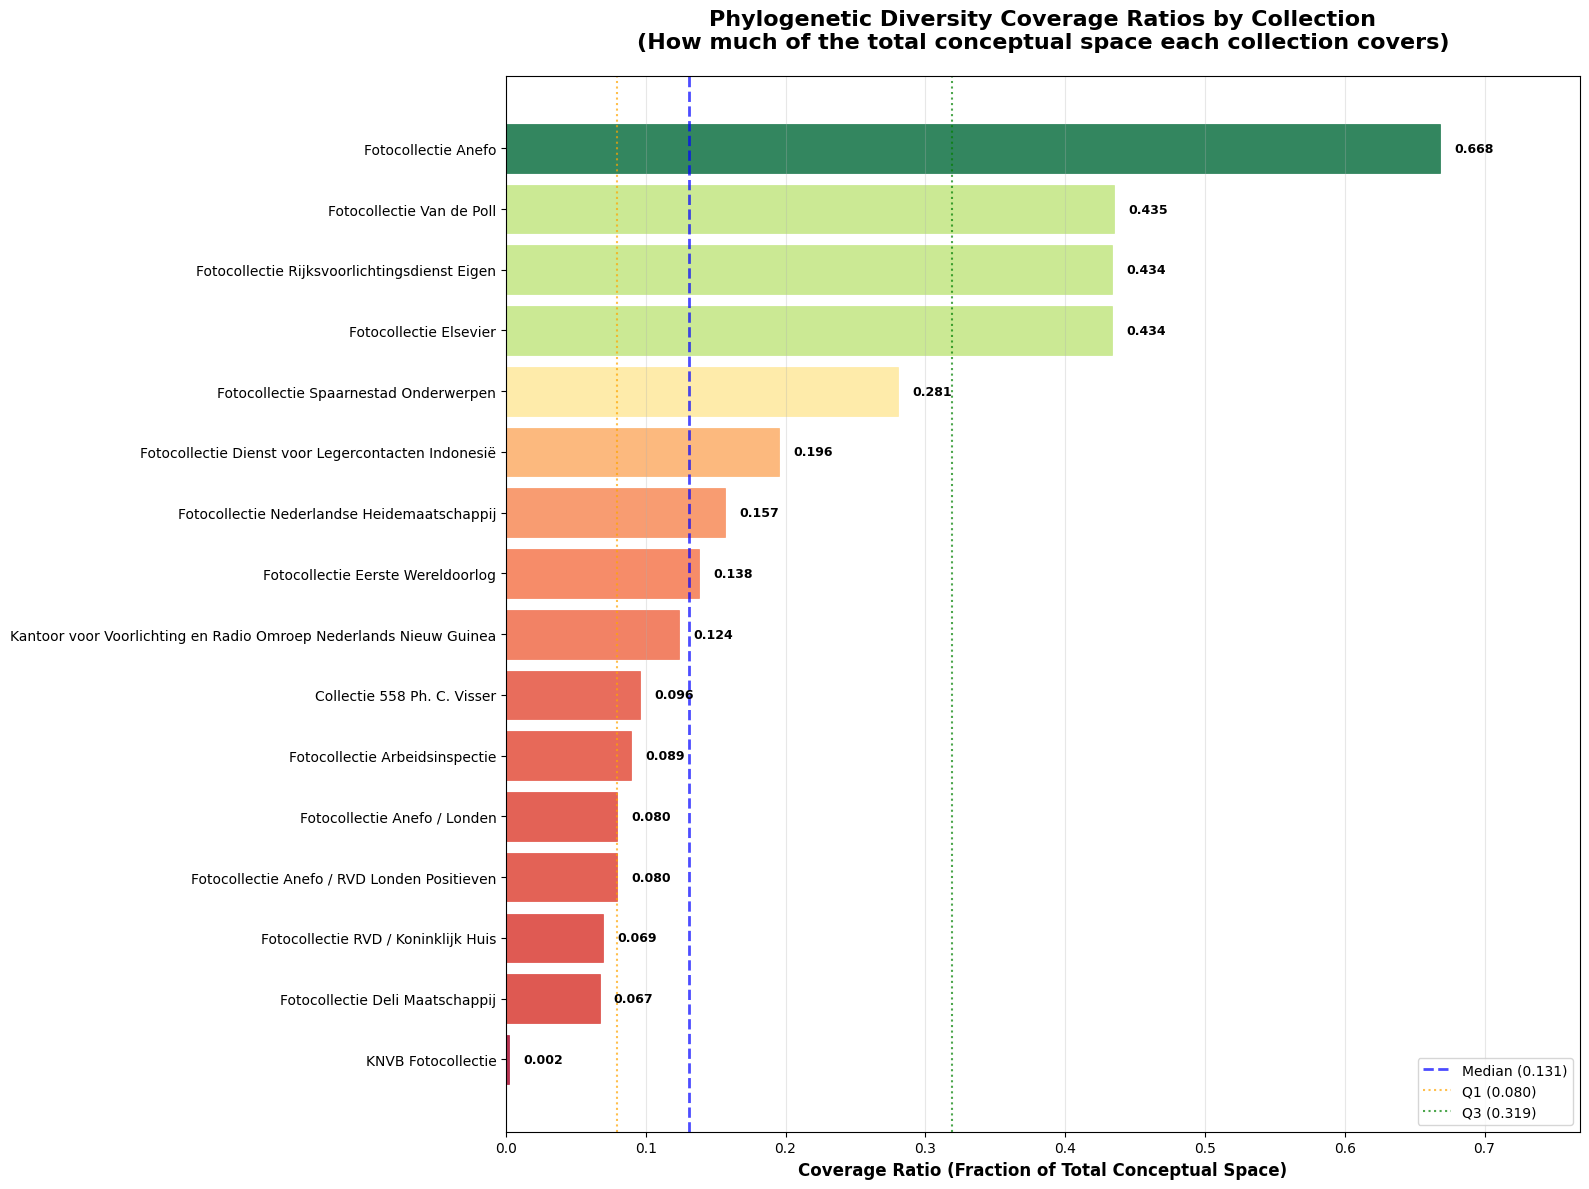

In [28]:
# 1. Coverage ratios ranked by collection
plt.figure(figsize=(16, 12))

# Sort data for better visualization
sorted_df = results_df.sort_values('coverage_ratio', ascending=True).reset_index(drop=True)

# Create horizontal bar chart
bars = plt.barh(range(len(sorted_df)), sorted_df['coverage_ratio'], 
                height=0.8, alpha=0.8, edgecolor='black', linewidth=0.5)

# Color bars with a gradient based on coverage ratio
colors = plt.cm.RdYlGn(sorted_df['coverage_ratio'] / sorted_df['coverage_ratio'].max())
for i, (bar, color) in enumerate(zip(bars, colors)):
    bar.set_color(color)

# Add value labels on bars
for i, (bar, ratio) in enumerate(zip(bars, sorted_df['coverage_ratio'])):
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{ratio:.3f}', ha='left', va='center', fontsize=9, fontweight='bold')

# Customize y-axis labels
plt.yticks(range(len(sorted_df)), sorted_df['subcollection'], fontsize=10)
plt.xlabel('Coverage Ratio (Fraction of Total Conceptual Space)', fontsize=12, fontweight='bold')
plt.title('Phylogenetic Diversity Coverage Ratios by Collection\n(How much of the total conceptual space each collection covers)', 
          fontsize=16, fontweight='bold', pad=20)

# Add reference lines
median_val = sorted_df['coverage_ratio'].median()
q25_val = sorted_df['coverage_ratio'].quantile(0.25)
q75_val = sorted_df['coverage_ratio'].quantile(0.75)

plt.axvline(x=median_val, color='blue', linestyle='--', alpha=0.7, linewidth=2, 
            label=f'Median ({median_val:.3f})')
plt.axvline(x=q25_val, color='orange', linestyle=':', alpha=0.7, linewidth=1.5, 
            label=f'Q1 ({q25_val:.3f})')
plt.axvline(x=q75_val, color='green', linestyle=':', alpha=0.7, linewidth=1.5, 
            label=f'Q3 ({q75_val:.3f})')

# Add grid and legend
plt.grid(True, alpha=0.3, axis='x')
plt.legend(loc='lower right', fontsize=10)


# Improve layout
plt.xlim(0, sorted_df['coverage_ratio'].max() * 1.15)  # Add 15% padding
plt.tight_layout()
plt.savefig('results/figures/coverage_ratios.png', dpi=300, bbox_inches='tight')
plt.show()

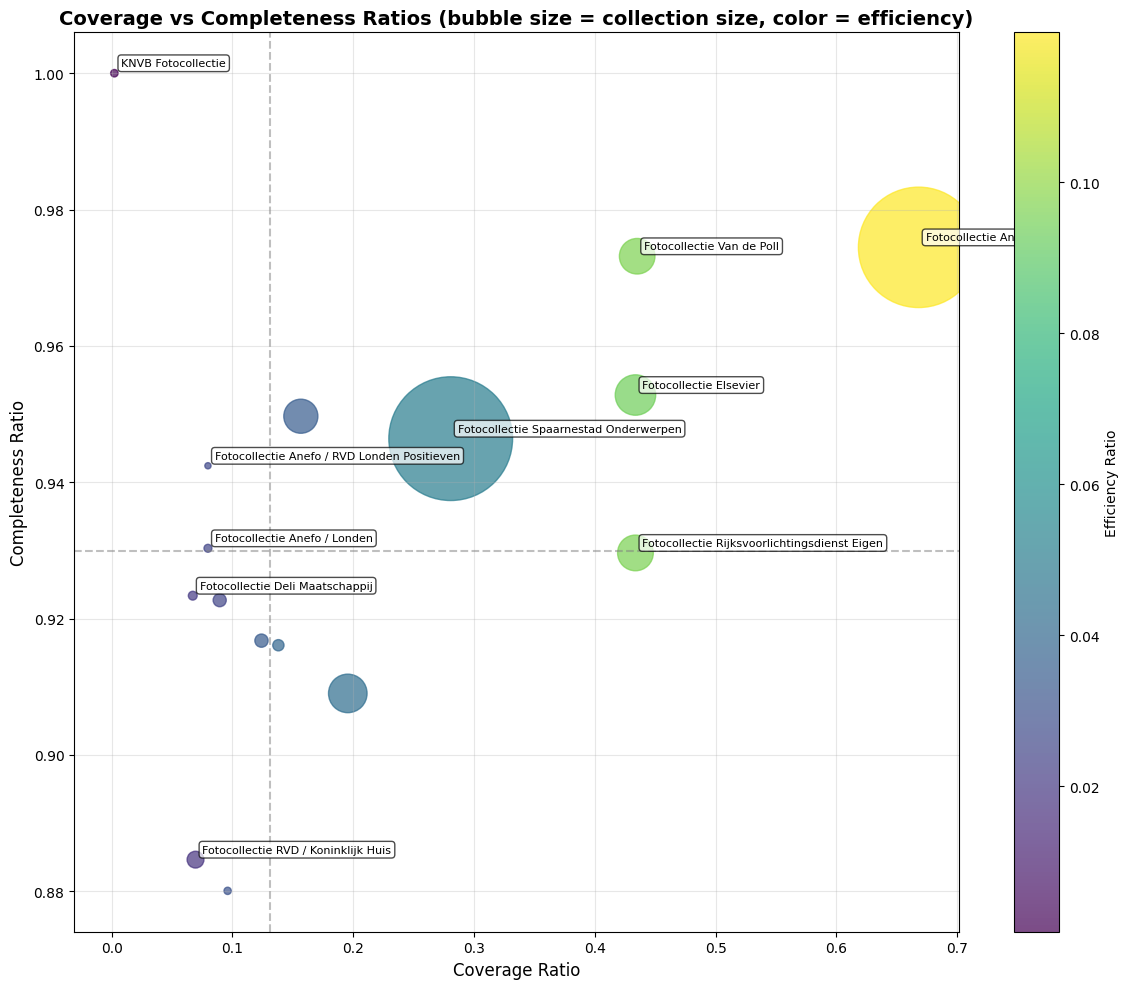

In [29]:
# 2. Scatter plot: Coverage vs Completeness with collection size as bubble size
plt.figure(figsize=(12, 10))

# Create scatter plot with size based on collection size
scatter = plt.scatter(results_df['coverage_ratio'], results_df['completeness_ratio'], 
                     s=results_df['collection_size']/50, alpha=0.7, c=results_df['efficiency_ratio'], 
                     cmap='viridis')

# Add collection labels for extreme points
for i, row in results_df.iterrows():
    # Label top 5 and bottom 5 collections
    if i < 5 or i >= len(results_df) - 5:
        plt.annotate(row['subcollection'], 
                    (row['coverage_ratio'], row['completeness_ratio']),
                    xytext=(5, 5), textcoords='offset points', fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.xlabel('Coverage Ratio', fontsize=12)
plt.ylabel('Completeness Ratio', fontsize=12)
plt.title('Coverage vs Completeness Ratios (bubble size = collection size, color = efficiency)', 
          fontsize=14, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Efficiency Ratio', fontsize=10)

# Add quadrant lines
plt.axhline(y=results_df['completeness_ratio'].median(), color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=results_df['coverage_ratio'].median(), color='gray', linestyle='--', alpha=0.5)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/coverage_vs_completeness_ratios.png', dpi=300, bbox_inches='tight')
plt.show()




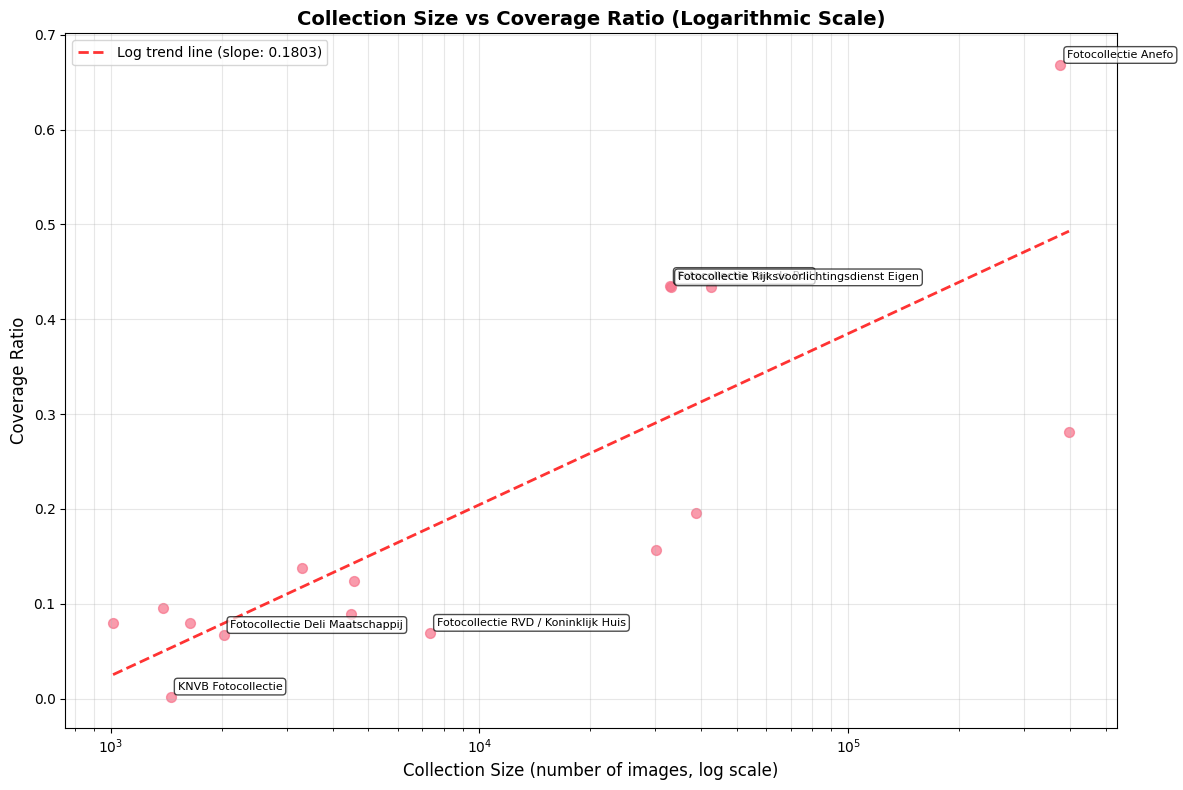

In [30]:
# 3. Collection sizes vs coverage ratios with trend line (log scale)
plt.figure(figsize=(12, 8))

# Scatter plot
plt.scatter(results_df['collection_size'], results_df['coverage_ratio'], alpha=0.7, s=50)

# Add trend line (using log of collection size for better fit on log scale)
log_sizes = np.log10(results_df['collection_size'])
z = np.polyfit(log_sizes, results_df['coverage_ratio'], 1)
# Create trend line points
x_trend = np.logspace(np.log10(results_df['collection_size'].min()), 
                      np.log10(results_df['collection_size'].max()), 100)
y_trend = z[0] * np.log10(x_trend) + z[1]
plt.plot(x_trend, y_trend, "r--", alpha=0.8, linewidth=2, 
         label=f'Log trend line (slope: {z[0]:.4f})')

# Add collection labels for extreme points
for idx, (i, row) in enumerate(results_df.iterrows()):
    if idx < 3 or idx >= len(results_df) - 3:  # Top and bottom 3
        plt.annotate(str(row['subcollection']), 
                    (float(row['collection_size']), float(row['coverage_ratio'])),
                    xytext=(5, 5), textcoords='offset points', fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# Set logarithmic scale for x-axis
plt.xscale('log')
plt.xlabel('Collection Size (number of images, log scale)', fontsize=12)
plt.ylabel('Coverage Ratio', fontsize=12)
plt.title('Collection Size vs Coverage Ratio (Logarithmic Scale)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, which='both')  # Show both major and minor grid lines
plt.tight_layout()
plt.savefig('results/figures/collection_size_vs_coverage_ratio.png', dpi=300, bbox_inches='tight')
plt.show()

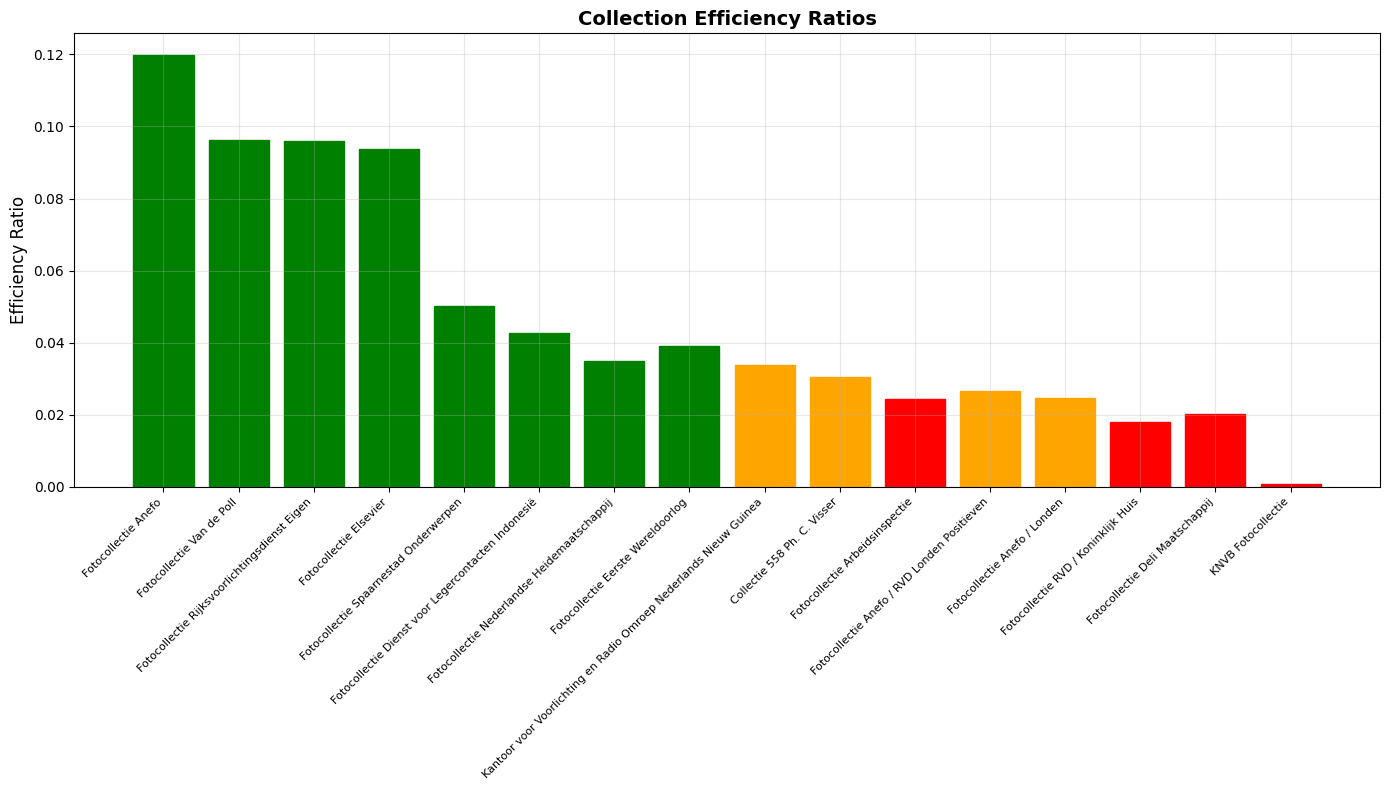

In [31]:
# 4. Efficiency ratios
plt.figure(figsize=(14, 8))
bars = plt.bar(range(len(results_df)), results_df['efficiency_ratio'])
plt.xticks(range(len(results_df)), results_df['subcollection'], 
           rotation=45, ha='right', fontsize=8)
plt.ylabel('Efficiency Ratio', fontsize=12)
plt.title('Collection Efficiency Ratios', fontsize=14, fontweight='bold')

# Color bars based on efficiency
for i, bar in enumerate(bars):
    if results_df.iloc[i]['efficiency_ratio'] > results_df['efficiency_ratio'].median():
        bar.set_color('green')
    elif results_df.iloc[i]['efficiency_ratio'] < results_df['efficiency_ratio'].quantile(0.25):
        bar.set_color('red')
    else:
        bar.set_color('orange')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/collection_efficiency_ratios.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Bias Pattern Analysis

In [34]:
print("🔍 BIAS PATTERN ANALYSIS")
print("=" * 50)

# Calculate medians for quadrant analysis
coverage_median = results_df['coverage_ratio'].median()
completeness_median = results_df['completeness_ratio'].median()

print(f"Reference values:")
print(f"  Coverage median: {coverage_median:.3f}")
print(f"  Completeness median: {completeness_median:.3f}")
print()

# 1. High Coverage + Low Completeness (Lower-Right quadrant)
# Collection touches many domains but is under-sampled in each. Good candidate for targeted expansion.
high_coverage_low_completeness = results_df[
    (results_df['coverage_ratio'] > coverage_median) &
    (results_df['completeness_ratio'] < completeness_median)
]

print(f"BROAD but UNDER-SAMPLED collections ({len(high_coverage_low_completeness)}):")
print("   High Coverage + Low Completeness - Good candidates for targeted expansion")
if len(high_coverage_low_completeness) > 0:
    for _, row in high_coverage_low_completeness.iterrows():
        print(f"   • {row['subcollection']}: Coverage={row['coverage_ratio']:.3f}, Completeness={row['completeness_ratio']:.3f}")
else:
    print("   None found")
print()

# 2. Low Coverage + Low Completeness (Lower-Left quadrant)
# This collection has both institutional blind spots AND incomplete sampling within its domain.
low_coverage_low_completeness = results_df[
    (results_df['coverage_ratio'] < coverage_median) &
    (results_df['completeness_ratio'] < completeness_median)
]

print(f"INSTITUTIONAL BLIND SPOTS with INCOMPLETE SAMPLING ({len(low_coverage_low_completeness)}):")
print("   Low Coverage + Low Completeness - Both institutional blind spots AND incomplete sampling")
if len(low_coverage_low_completeness) > 0:
    for _, row in low_coverage_low_completeness.iterrows():
        print(f"   • {row['subcollection']}: Coverage={row['coverage_ratio']:.3f}, Completeness={row['completeness_ratio']:.3f}")
else:
    print("   None found")
print()

# 3. Low Coverage + High Completeness (Upper-Left quadrant)
# This collection thoroughly documents its narrow domain. The low coverage reflects institutional focus, not sampling bias.
low_coverage_high_completeness = results_df[
    (results_df['coverage_ratio'] < coverage_median) &
    (results_df['completeness_ratio'] > completeness_median)
]

print(f"NARROW but THOROUGH documentation ({len(low_coverage_high_completeness)}):")
print("   Low Coverage + High Completeness - Thorough documentation of narrow domain (institutional focus)")
if len(low_coverage_high_completeness) > 0:
    for _, row in low_coverage_high_completeness.iterrows():
        print(f"   • {row['subcollection']}: Coverage={row['coverage_ratio']:.3f}, Completeness={row['completeness_ratio']:.3f}")
else:
    print("   None found")
print()

# 4. High Coverage + High Completeness (Upper-Right quadrant)
# WOW! Excellent coverage and thoroughness
high_coverage_high_completeness = results_df[
    (results_df['coverage_ratio'] > coverage_median) &
    (results_df['completeness_ratio'] > completeness_median)
]

print(f"EXCELLENT collections - WOW! ({len(high_coverage_high_completeness)}):")
print("   High Coverage + High Completeness - Outstanding performance")
if len(high_coverage_high_completeness) > 0:
    for _, row in high_coverage_high_completeness.iterrows():
        print(f"   • {row['subcollection']}: Coverage={row['coverage_ratio']:.3f}, Completeness={row['completeness_ratio']:.3f}")
else:
    print("   None found")
print()

# Additional analysis: Extreme cases
print("EXTREME CASES:")

# Lowest coverage collections
lowest_coverage = results_df.nsmallest(3, 'coverage_ratio')
print(f"   Lowest Coverage Collections:")
for _, row in lowest_coverage.iterrows():
    print(f"     • {row['subcollection']}: {row['coverage_ratio']:.4f}")

# Highest coverage collections
highest_coverage = results_df.nlargest(3, 'coverage_ratio')
print(f"   Highest Coverage Collections:")
for _, row in highest_coverage.iterrows():
    print(f"     • {row['subcollection']}: {row['coverage_ratio']:.4f}")

🔍 BIAS PATTERN ANALYSIS
Reference values:
  Coverage median: 0.131
  Completeness median: 0.930

BROAD but UNDER-SAMPLED collections (3):
   High Coverage + Low Completeness - Good candidates for targeted expansion
   • Fotocollectie Rijksvoorlichtingsdienst Eigen: Coverage=0.434, Completeness=0.930
   • Fotocollectie Dienst voor Legercontacten Indonesië: Coverage=0.196, Completeness=0.909
   • Fotocollectie Eerste Wereldoorlog: Coverage=0.138, Completeness=0.916

INSTITUTIONAL BLIND SPOTS with INCOMPLETE SAMPLING (5):
   Low Coverage + Low Completeness - Both institutional blind spots AND incomplete sampling
   • Kantoor voor Voorlichting en Radio Omroep Nederlands Nieuw Guinea: Coverage=0.124, Completeness=0.917
   • Collectie 558 Ph. C. Visser: Coverage=0.096, Completeness=0.880
   • Fotocollectie Arbeidsinspectie: Coverage=0.089, Completeness=0.923
   • Fotocollectie RVD / Koninklijk Huis: Coverage=0.069, Completeness=0.885
   • Fotocollectie Deli Maatschappij: Coverage=0.067, Comp

## 7. Interactive Exploration

In [36]:
# Interactive collection explorer
def explore_collection(collection_name):
    """Explore details for a specific collection."""
    if collection_name not in results_df['subcollection'].values:
        print(f"Collection '{collection_name}' not found")
        return
    
    collection = results_df[results_df['subcollection'] == collection_name].iloc[0]
    
    print(f"🔍 DETAILED ANALYSIS: {collection_name}")
    print("=" * 50)
    print(f"Collection PD: {collection['collection_pd']:.2f}")
    print(f"Global GTAA PD: {results['global_pd']:.2f}")
    print(f"Coverage Ratio: {collection['coverage_ratio']:.4f} ({collection['coverage_ratio']*100:.2f}%)")
    print(f"Completeness Ratio: {collection['completeness_ratio']:.4f} ({collection['completeness_ratio']*100:.2f}%)")
    print(f"Efficiency Ratio: {collection['efficiency_ratio']:.4f}")
    print(f"Collection Size: {collection['collection_size']:,} images")
    print(f"Unique Subjects: {collection['n_unique_subjects']:,}")
    print(f"Unseen PD: {collection['unseen_pd']:.2f}")
    

    # Calculate medians for quadrant analysis
    coverage_median = results_df['coverage_ratio'].median()
    completeness_median = results_df['completeness_ratio'].median()

    print(f"\nQUADRANT ANALYSIS:")
    if collection['coverage_ratio'] > coverage_median and collection['completeness_ratio'] < completeness_median:
        print("BROAD but UNDER-SAMPLED: Good candidate for targeted expansion")
    elif collection['coverage_ratio'] < coverage_median and collection['completeness_ratio'] < completeness_median:
        print("INSTITUTIONAL BLIND SPOT + INCOMPLETE: Both scope and sampling issues")
    elif collection['coverage_ratio'] < coverage_median and collection['completeness_ratio'] > completeness_median:
        print("NARROW but THOROUGH: Institutional focus, not sampling bias")
    elif collection['coverage_ratio'] > coverage_median and collection['completeness_ratio'] > completeness_median:
        print("WOW! EXCELLENT: Outstanding coverage and thoroughness")

# Example usage - explore a specific collection
if len(results_df) > 0:
    # Explore the top collection
    top_collection = results_df.iloc[0]['subcollection']
    explore_collection(top_collection)
    
    print(f"\n💡 To explore other collections, use: explore_collection('Collection Name')")
    print(f"Available collections: {list(results_df['subcollection'].values)}")

🔍 DETAILED ANALYSIS: Fotocollectie Anefo
Collection PD: 2337.00
Global GTAA PD: 3498.00
Coverage Ratio: 0.6681 (66.81%)
Completeness Ratio: 0.9745 (97.45%)
Efficiency Ratio: 0.1198
Collection Size: 376,056 images
Unique Subjects: 2,250
Unseen PD: 61.25

QUADRANT ANALYSIS:
WOW! EXCELLENT: Outstanding coverage and thoroughness

💡 To explore other collections, use: explore_collection('Collection Name')
Available collections: ['Fotocollectie Anefo', 'Fotocollectie Van de Poll', 'Fotocollectie Rijksvoorlichtingsdienst Eigen', 'Fotocollectie Elsevier', 'Fotocollectie Spaarnestad Onderwerpen', 'Fotocollectie Dienst voor Legercontacten Indonesië', 'Fotocollectie Nederlandse Heidemaatschappij', 'Fotocollectie Eerste Wereldoorlog', 'Kantoor voor Voorlichting en Radio Omroep Nederlands Nieuw Guinea', 'Collectie 558 Ph. C. Visser', 'Fotocollectie Arbeidsinspectie', 'Fotocollectie Anefo / RVD Londen Positieven', 'Fotocollectie Anefo / Londen', 'Fotocollectie RVD / Koninklijk Huis', 'Fotocollectie D

## 8. Save Results

In [39]:
# Save results to files
output_dir = Path("results/")
output_dir.mkdir(parents=True, exist_ok=True)

# Save results CSV
detailed_df = results_df.copy()
detailed_df['coverage_percentage'] = detailed_df['coverage_ratio'] * 100
detailed_df['completeness_percentage'] = detailed_df['completeness_ratio'] * 100
detailed_path = output_dir / "archival_bias_detailed.csv"
detailed_df.to_csv(detailed_path, index=False)
print(f"Results saved to: {detailed_path}")

Detailed results saved to: results/archival_bias_detailed.csv
